In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

Dados salvos com sucesso em G051Dataset_US29.csv


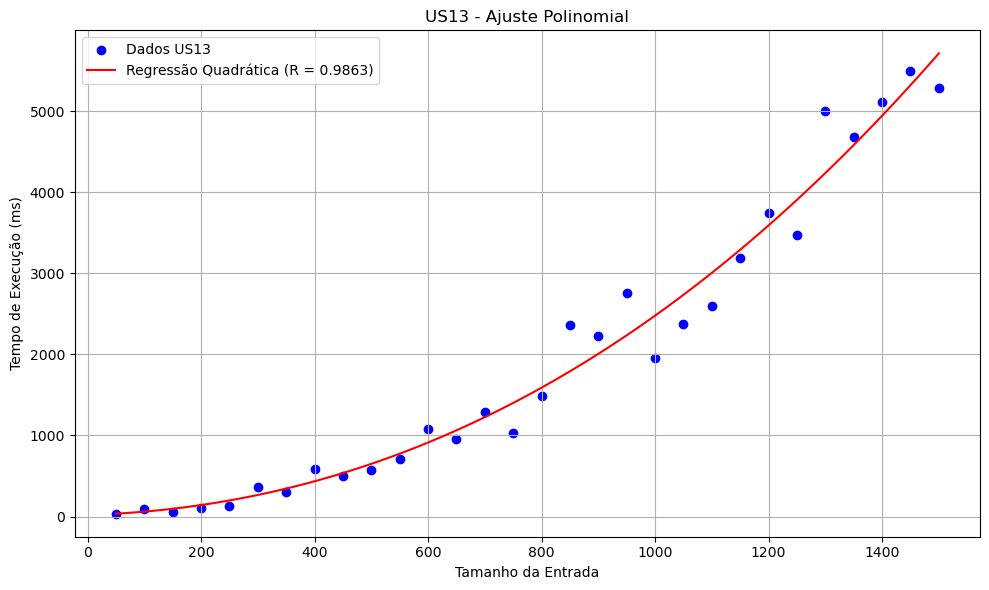

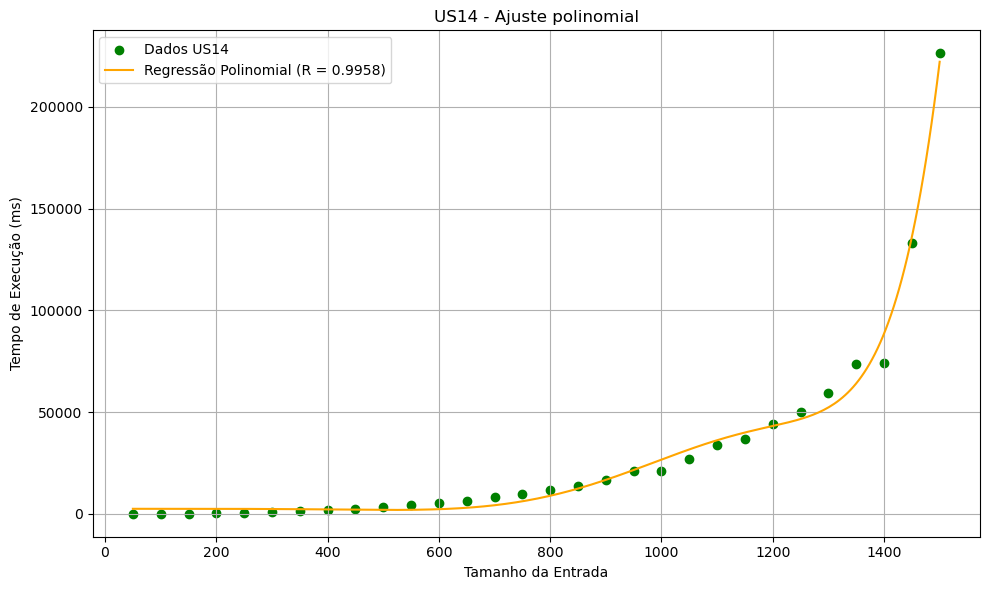

In [18]:
# Dados
sizes = np.array([50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500]).reshape(-1, 1)

us13 = np.array([35.123456, 89.654321, 54.891234, 106.987654, 134.567890, 
    366.543210, 307.654321, 590.123456, 503.210987, 575.432109, 
    715.678901, 1077.654321, 959.876543, 1286.543210, 1030.123456, 
    1484.567890, 2366.789012, 2226.543210, 2754.321098, 1959.876543, 
    2372.109876, 2597.654321, 3182.109876, 3739.876543, 3467.654321, 
    4998.765432, 4680.123456, 5106.543210, 5491.098765, 5287.654321])

us14 = np.array([76.543210, 89.012345, 157.654321, 296.543210, 487.654321, 
    770.123456, 1253.456789, 1758.765432, 2633.456789, 3169.876543, 
    4184.567890, 5185.432109, 6530.123456, 8266.543210, 9632.109876, 
    11929.012345, 13827.654321, 16647.654321, 20954.321098, 20971.098765, 
    26935.432109, 33941.098765, 36930.123456, 44406.543210, 50241.098765, 
    59415.432109, 73597.654321, 74164.567890, 133098.765432, 226314.567890])

# Função para calcular R
def calculate_R(X, y, degree):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    predictions = model.predict(X)
    R, _ = pearsonr(y, predictions)
    return R

# Cálculo de R
R_quad_us13 = calculate_R(sizes, us13, degree=3)
R_quad_us14 = calculate_R(sizes, us14, degree=9)

# Modelos ajustados
model_us13 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
model_us13.fit(sizes, us13)

model_us14 = make_pipeline(PolynomialFeatures(degree=9), LinearRegression())
model_us14.fit(sizes, us14)

# Previsões
X_range = np.linspace(sizes.min(), sizes.max(), 300).reshape(-1, 1)
y_pred_us13 = model_us13.predict(X_range)
y_pred_us14 = model_us14.predict(X_range)

# Gráfico US13
plt.figure(figsize=(10, 6))
plt.scatter(sizes, us13, color='blue', label='Dados US13')
plt.plot(X_range, y_pred_us13, color='red', label=f'Regressão Quadrática (R = {R_quad_us13:.4f})')
plt.title('US13 - Ajuste Polinomial')
plt.xlabel('Tamanho da Entrada')
plt.ylabel('Tempo de Execução (ms)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico US14
plt.figure(figsize=(10, 6))
plt.scatter(sizes, us14, color='green', label='Dados US14')
plt.plot(X_range, y_pred_us14, color='orange', label=f'Regressão Polinomial (R = {R_quad_us14:.4f})')
plt.title('US14 - Ajuste polinomial')
plt.xlabel('Tamanho da Entrada')
plt.ylabel('Tempo de Execução (ms)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Enter station name:  Hamburg
Enter year:  2020



Analysis for Hamburg in 2020:
- Cargo with highest correlation to revenue: Iron (r = 0.9111)

Linear Regression Summary:
- Slope: 0.8716
- Intercept: 351.3873
- R² (coefficient of determination): 0.8301
- SQE: 450132.8329

Prediction for January 2021 with +10% cargo:
- New cargo amount: 487.42 units
- 95% Confidence Interval: (€635.55, €916.94)
- 95% Prediction Interval: (€283.02, €1269.47)


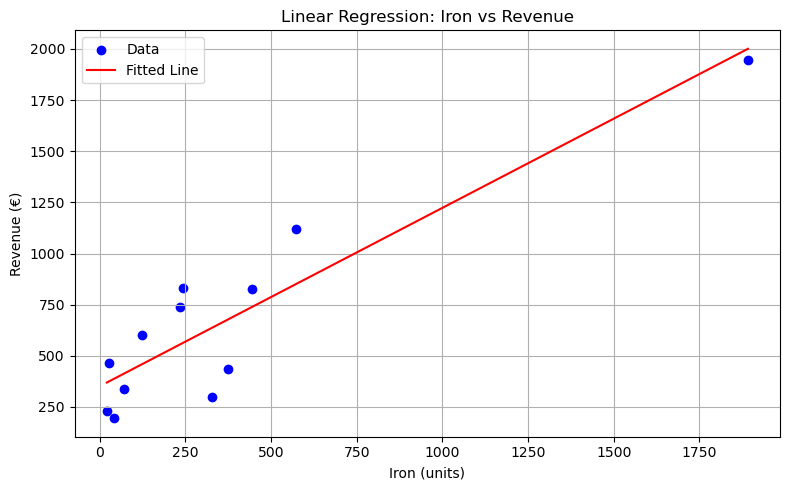

In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

def load_data(file_path):
    df = pd.read_csv(file_path, delimiter=';', decimal=',')
    cargo_cols = ['Iron', 'Coal', 'Steel', 'Vegetables', 'Cereals', 'Wool', 'Coffee', 'Cattle', 'Passengers', 'Mail']
    return df, cargo_cols

def cargo_revenue_analysis(df, cargo_cols, station, year):
    station_year_data = df[(df['Station'] == station) & (df['Year'] == year)]
    if station_year_data.empty:
        return None, "No data available for the specified station and year."
    
    # Calcular correlações
    correlations = {}
    for cargo in cargo_cols:
        if station_year_data[cargo].isnull().any() or station_year_data['Revenues'].isnull().any():
            continue
        corr, _ = stats.pearsonr(station_year_data[cargo], station_year_data['Revenues'])
        correlations[cargo] = corr
    
    if not correlations:
        return None, "No valid correlations."

    # Selecionar carga com maior correlação
    selected_cargo = max(correlations, key=lambda k: abs(correlations[k]))
    max_corr = correlations[selected_cargo]

    # Regressão linear
    X = station_year_data[selected_cargo]
    y = station_year_data['Revenues']
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()

    # Previsão com 10% a mais que dezembro
    dec_data = station_year_data[station_year_data['Month'] == 12]
    if dec_data.empty:
        return None, "December data not available for prediction."
    dec_cargo = dec_data[selected_cargo].values[0]
    next_jan_cargo = dec_cargo * 1.10
    pred_input = np.array([[1, next_jan_cargo]])

    prediction = model.get_prediction(pred_input)
    pred_frame = prediction.summary_frame(alpha=0.05)
    
    pred_revenue = pred_frame['mean'].iloc[0]
    ci_low, ci_high = pred_frame['mean_ci_lower'].iloc[0], pred_frame['mean_ci_upper'].iloc[0]
    pi_low, pi_high = pred_frame['obs_ci_lower'].iloc[0], pred_frame['obs_ci_upper'].iloc[0]

    # --- SQE pelo método dos mínimos quadrados ---
    x = X.values
    y_actual = y.values
    x_mean = np.mean(x)
    y_mean = np.mean(y_actual)

    Sxx = np.sum((x - x_mean) ** 2)
    Sxy = np.sum((x - x_mean) * (y_actual - y_mean))
    Syy = np.sum((y_actual - y_mean) ** 2)
    sqe = Syy - (Sxy ** 2) / Sxx

    results = {
        'selected_cargo': selected_cargo,
        'correlation': max_corr,
        'slope': model.params[selected_cargo],
        'intercept': model.params['const'],
        'r_squared': model.rsquared,
        'std_err': model.bse[selected_cargo],
        'predicted_revenue': pred_revenue,
        'confidence_interval': (ci_low, ci_high),
        'prediction_interval': (pi_low, pi_high),
        'residual_sum_squares': sqe,
        'next_cargo_amount': next_jan_cargo,
        'x': X,
        'y': y,
        'model': model
    }
    return results, None
    
def plot_regression(x, y, model, cargo_name):
    x_vals = np.linspace(x.min(), x.max(), 100)
    x_const = sm.add_constant(x_vals)
    y_pred = model.predict(x_const)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data')
    plt.plot(x_vals, y_pred, color='red', label='Fitted Line')
    plt.xlabel(f'{cargo_name} (units)')
    plt.ylabel('Revenue (€)')
    plt.title(f'Linear Regression: {cargo_name} vs Revenue')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    df, cargo_cols = load_data('Stations_Data.csv')
    station = input("Enter station name: ").strip()
    year = int(input("Enter year: "))

    results, error = cargo_revenue_analysis(df, cargo_cols, station, year)

    if error:
        print(error)
    else:
        print(f"\nAnalysis for {station} in {year}:")
        print(f"- Cargo with highest correlation to revenue: {results['selected_cargo']} (r = {results['correlation']:.4f})")
        print("\nLinear Regression Summary:")
        print(f"- Slope: {results['slope']:.4f}")
        print(f"- Intercept: {results['intercept']:.4f}")
        print(f"- R² (coefficient of determination): {results['r_squared']:.4f}")
        print(f"- SQE: {results['residual_sum_squares']:.4f}")

        print(f"\nPrediction for January {year + 1} with +10% cargo:")
        print(f"- New cargo amount: {results['next_cargo_amount']:.2f} units")
        print(f"- 95% Confidence Interval: (€{results['confidence_interval'][0]:.2f}, €{results['confidence_interval'][1]:.2f})")
        print(f"- 95% Prediction Interval: (€{results['prediction_interval'][0]:.2f}, €{results['prediction_interval'][1]:.2f})")

        plot_regression(results['x'], results['y'], results['model'], results['selected_cargo'])